<a href="https://colab.research.google.com/github/vikkikumar1/ResumeIQ_AI/blob/main/jupyter_notebook/1.EDA_Data_prep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exploratory Data Analysis & Data Preparation-
Objectives:-

 Load and explore the resume dataset
 Perform Comprehensive EDA
 Assess data quality
 Clean and prepare data for modeling

In [ ]:
!pip install pandas numpy scikit-learn spacy sentence-transformers rapidfuzz pdfplumber PyPDF2 python-docx
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 57.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install langchain langchain-core langchain-community pypdf pymupdf sentence-transformers chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 112.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.9/343.9 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 93.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/20

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")


Libraries imported successfully!


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/resumeJD_Pairs_Version2.csv")

print(f"Data Loaded Successfully: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")

Data Loaded Successfully: 320 rows, 4 columns

Columns: ['resume_text', 'job_description', 'match_score', 'match_label']


In [ ]:
# First look at the data
print("First 5 rows:")
df.head()

First 5 rows:


,resume_text,job_description,match_score,match_label
0,Experienced Cloud Engineer with 3 years of exp...,We are hiring a Cloud Engineer. Required skill...,0.80,high
1,Experienced Full Stack Developer with 5 years ...,We are hiring a Full Stack Developer. Required...,0.83,high
2,Experienced Cloud Engineer with 3 years of exp...,We are hiring a Cloud Engineer. Required skill...,0.90,high
3,Experienced Business Analyst with 3 years of e...,We are hiring a Business Analyst. Required ski...,0.89,high
4,Experienced Data Analyst with 2 years of exper...,We are hiring a Data Analyst. Required skills:...,0.81,high


In [ ]:
# dataset information
print("Dataset Info:")
print("=" * 60)
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resume_text      268 non-null    object 
 1   job_description  268 non-null    object 
 2   match_score      320 non-null    float64
 3   match_label      320 non-null    object 
dtypes: float64(1), object(3)
memory usage: 10.1+ KB


In [ ]:
# statistical summary
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,match_score
count,320.000000
mean,0.537938
std,0.341138
min,0.000000
25%,0.160000
50%,0.630000
75%,0.830000
max,0.950000


In [ ]:
# text columns summary
print("\nText Columns Summary:")
df.describe(include='object')


Text Columns Summary:


,resume_text,job_description,match_label
count,268,268,320
unique,53,6,3
top,Experienced Cybersecurity Analyst with 7 years...,We are hiring a Cybersecurity Analyst. Require...,high
freq,11,53,118


In [ ]:
# Check for the missing values
print("Missing Values Analysis:")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})
print(missing_df)
print(f"\nTotal missing values: {missing.sum()}")

Missing Values Analysis:
                 Missing_Count  Percentage
resume_text                 52       16.25
job_description             52       16.25
match_score                  0        0.00
match_label                  0        0.00

Total missing values: 104


In [ ]:
# ─── Section: Uniqueness Checks ───────────────────────────────────────────────

print(f"Total rows:          {len(df)}")
print(f"Unique resumes:      {df['resume_text'].nunique()}")
print(f"Unique JDs:          {df['job_description'].nunique()}")
print(f"Unique resume+JD pairs: {df[['resume_text','job_description']].drop_duplicates().shape[0]}")

Total rows:          320
Unique resumes:      53
Unique JDs:          6
Unique resume+JD pairs: 54


In [ ]:
# ─── Section: Label Consistency ───────────────────────────────────────────────

# What labels exist? (spot the case inconsistency!)
print("Unique labels found:")
print(df['match_label'].value_counts())

# Is the casing consistent?
print(f"\nExpected 3 labels, got: {df['match_label'].nunique()} unique values")
print("Distinct values:", df['match_label'].unique())

Unique labels found:
match_label
high      118
low       115
medium     87
Name: count, dtype: int64

Expected 3 labels, got: 3 unique values
Distinct values: ['high' 'medium' 'low']


In [ ]:
print("Score distribution:")
print(df['match_score'].describe())
print()

# Scores must be between 0.0 and 1.0 — flag the bad ones
invalid_scores = df[(df['match_score'] < 0) | (df['match_score'] > 1)]
print(f"Invalid scores (out of 0–1 range): {len(invalid_scores)}")
print(invalid_scores[['match_label', 'match_score']])

Score distribution:
count    320.000000
mean       0.537938
std        0.341138
min        0.000000
25%        0.160000
50%        0.630000
75%        0.830000
max        0.950000
Name: match_score, dtype: float64

Invalid scores (out of 0–1 range): 0
Empty DataFrame
Columns: [match_label, match_score]
Index: []


In [ ]:
# ─── Section: Label vs Score Sanity Check ─────────────────────────────────────
# Do scores actually match what the label says?

print("Score stats per label (after lowercasing):")
df['match_label_lower'] = df['match_label'].str.lower()
print(df.groupby('match_label_lower')['match_score'].describe().round(2))

# Expected:
#   high   → 0.75 – 0.95
#   medium → 0.40 – 0.70
#   low    → 0.05 – 0.35

Score stats per label (after lowercasing):
                   count  mean   std  min   25%   50%   75%   max
match_label_lower                                                
high               118.0  0.87  0.04  0.8  0.82  0.87  0.91  0.95
low                115.0  0.12  0.15  0.0  0.00  0.05  0.24  0.46
medium              87.0  0.64  0.08  0.5  0.57  0.63  0.72  0.79


In [ ]:
# ─── Section: Null Values ─────────────────────────────────────────────────────

print("Missing values per column:")
print(df.isnull().sum())
print()

# Show the rows with nulls
nulls = df[df.isnull().any(axis=1)]
print(f"Rows with at least one null: {len(nulls)}")
nulls[['match_label', 'match_score']].head(10)

Missing values per column:
resume_text          52
job_description      52
match_score           0
match_label           0
match_label_lower     0
dtype: int64

Rows with at least one null: 52


,match_label,match_score
266,low,0.0
267,low,0.0
268,low,0.0
269,low,0.0
270,low,0.0
271,low,0.0
272,low,0.0
273,low,0.0
274,low,0.0
275,low,0.0


In [ ]:
# ─── Summary: All issues found ────────────────────────────────────────────────

print("=" * 50)
print("DATA QUALITY REPORT — merged_dataset.csv")
print("=" * 50)
print(f"  Total rows:             {len(df)}")
print(f"  Full duplicates:        {df.duplicated().sum()}")
print(f"  Duplicate pairs:        {df.duplicated(subset=['resume_text','job_description']).sum()}")
print(f"  Null resume_text:       {df['resume_text'].isnull().sum()}")
print(f"  Null job_description:   {df['job_description'].isnull().sum()}")
print(f"  Label case variants:    {df['match_label'].nunique()} (expected 3)")
print(f"  Invalid scores (<0/>1): {((df['match_score'] < 0) | (df['match_score'] > 1)).sum()}")
print("=" * 50)

DATA QUALITY REPORT — merged_dataset.csv
  Total rows:             320
  Full duplicates:        62
  Duplicate pairs:        266
  Null resume_text:       52
  Null job_description:   52
  Label case variants:    3 (expected 3)
  Invalid scores (<0/>1): 0


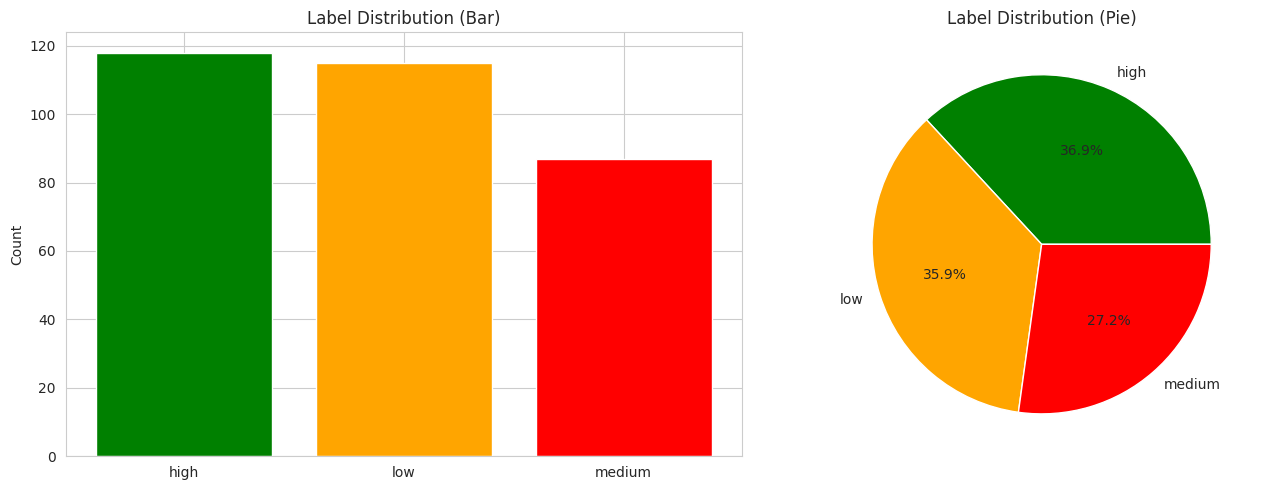

In [ ]:
# Pie chart + bar side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['match_label'].str.lower().value_counts()

axes[0].bar(counts.index, counts.values, color=['green','orange','red'])
axes[0].set_title('Label Distribution (Bar)')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['green','orange','red'])
axes[1].set_title('Label Distribution (Pie)')

plt.tight_layout()
plt.show()

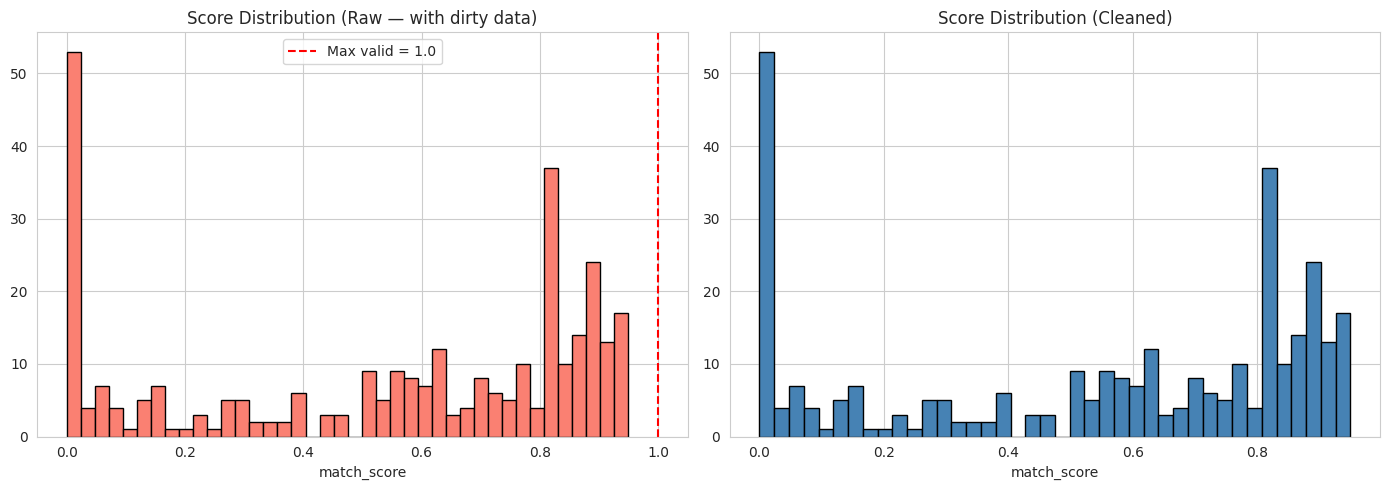

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before cleaning
axes[0].hist(df['match_score'], bins=40, color='salmon', edgecolor='black')
axes[0].set_title('Score Distribution (Raw — with dirty data)')
axes[0].set_xlabel('match_score')
axes[0].axvline(1.0, color='red', linestyle='--', label='Max valid = 1.0')
axes[0].legend()

# After cleaning
clean = df[(df['match_score'] >= 0) & (df['match_score'] <= 1)]
axes[1].hist(clean['match_score'], bins=40, color='steelblue', edgecolor='black')
axes[1].set_title('Score Distribution (Cleaned)')
axes[1].set_xlabel('match_score')

plt.tight_layout()
plt.show()

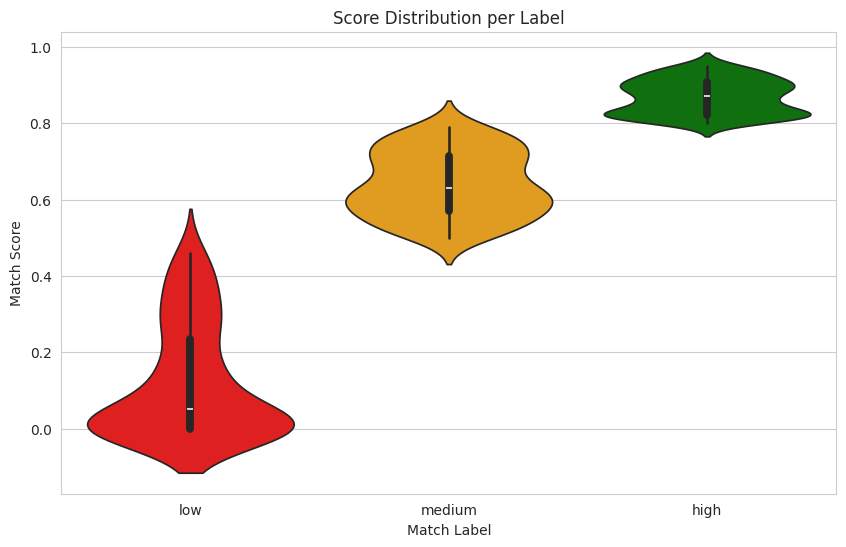

In [ ]:
import seaborn as sns

df_plot = df.copy()
df_plot['match_label'] = df_plot['match_label'].str.lower()
df_plot = df_plot[(df_plot['match_score'] >= 0) & (df_plot['match_score'] <= 1)]

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_plot, x='match_label', y='match_score',
               order=['low','medium','high'],
               palette=['red','orange','green'])
plt.title('Score Distribution per Label')
plt.xlabel('Match Label')
plt.ylabel('Match Score')
plt.show()

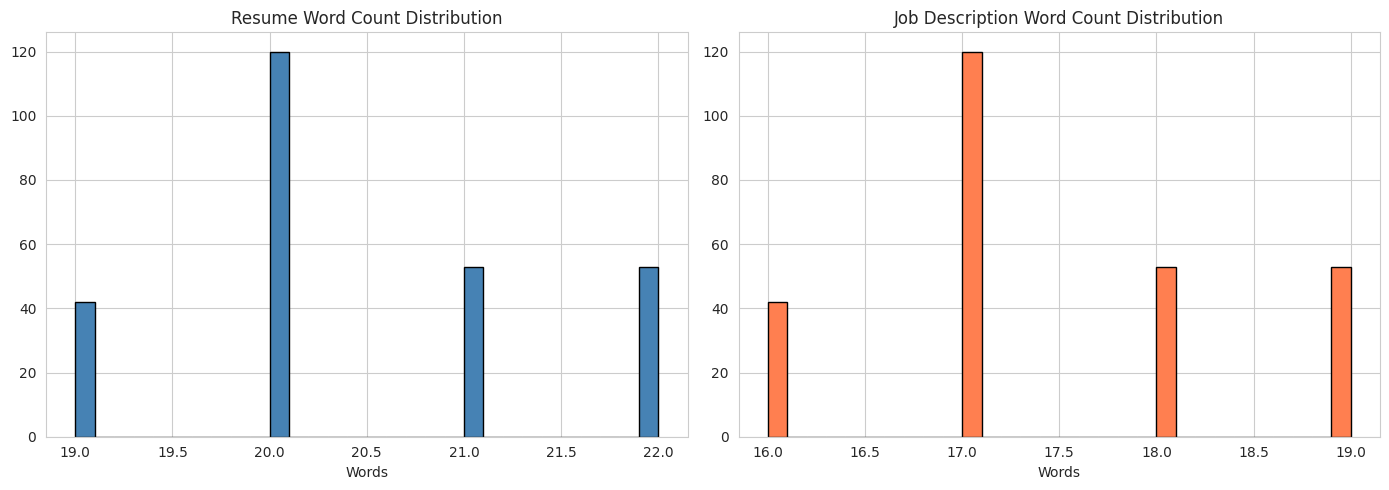

In [ ]:
df_plot['resume_len'] = df_plot['resume_text'].str.split().str.len()
df_plot['jd_len']     = df_plot['job_description'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_plot['resume_len'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Resume Word Count Distribution')
axes[0].set_xlabel('Words')

axes[1].hist(df_plot['jd_len'], bins=30, color='coral', edgecolor='black')
axes[1].set_title('Job Description Word Count Distribution')
axes[1].set_xlabel('Words')

plt.tight_layout()
plt.show()

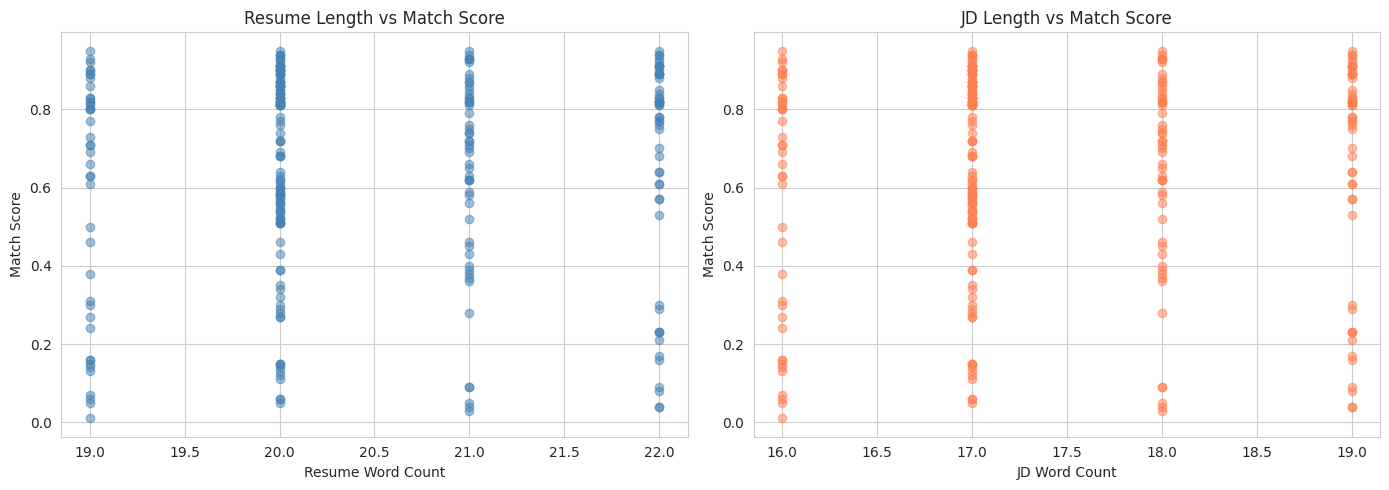

Resume length correlation: 0.063
JD length correlation:     0.063


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_plot['resume_len'], df_plot['match_score'], alpha=0.5, color='steelblue')
axes[0].set_xlabel('Resume Word Count')
axes[0].set_ylabel('Match Score')
axes[0].set_title('Resume Length vs Match Score')

axes[1].scatter(df_plot['jd_len'], df_plot['match_score'], alpha=0.5, color='coral')
axes[1].set_xlabel('JD Word Count')
axes[1].set_ylabel('Match Score')
axes[1].set_title('JD Length vs Match Score')

plt.tight_layout()
plt.show()

# Actual correlation values
print("Resume length correlation:", df_plot['resume_len'].corr(df_plot['match_score']).round(3))
print("JD length correlation:    ", df_plot['jd_len'].corr(df_plot['match_score']).round(3))

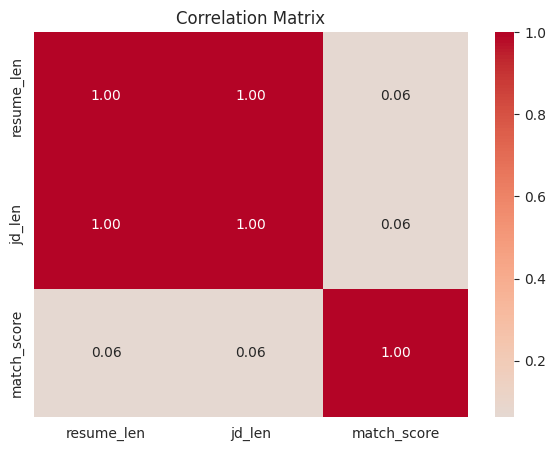

In [ ]:
plt.figure(figsize=(7, 5))
corr = df_plot[['resume_len', 'jd_len', 'match_score']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [ ]:
pip install wordcloud

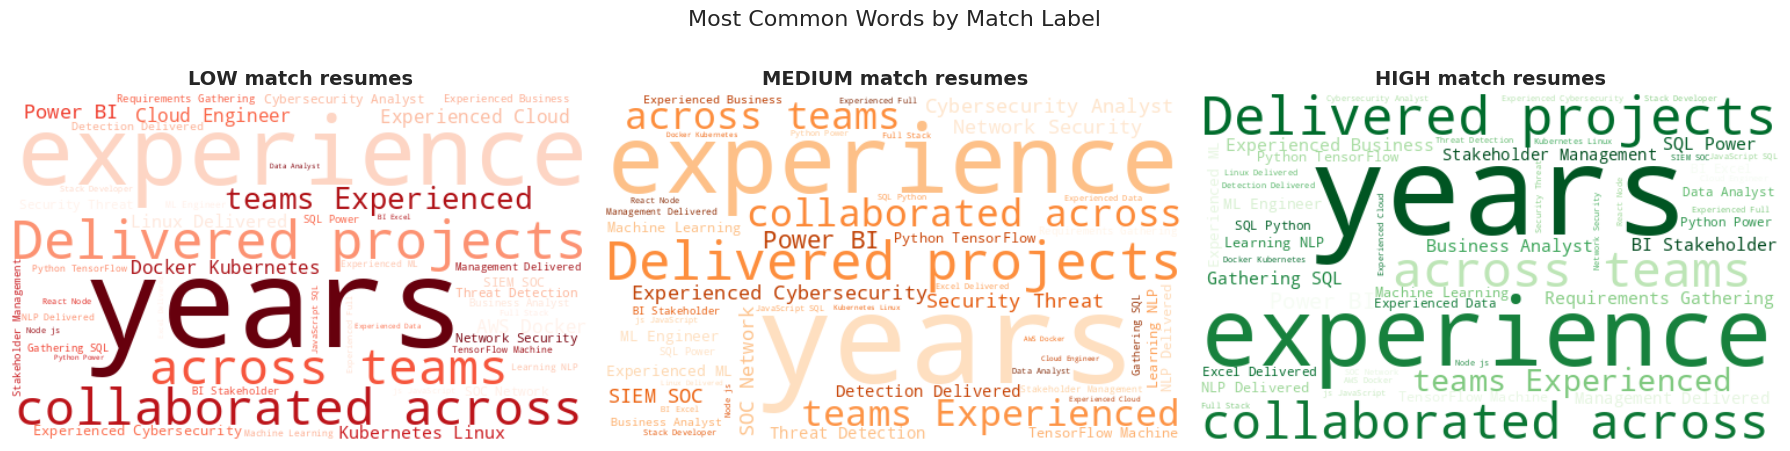

In [ ]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels  = ['low', 'medium', 'high']
colors  = ['Reds', 'Oranges', 'Greens']

for ax, label, cmap in zip(axes, labels, colors):
    text = ' '.join(df_plot[df_plot['match_label'] == label]['resume_text'].dropna())
    wc = WordCloud(width=500, height=300, background_color='white',
                   colormap=cmap, max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label.upper()} match resumes', fontsize=14, fontweight='bold')

plt.suptitle('Most Common Words by Match Label', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Always record the starting point so that you  can see what changed
print("BEFORE CLEANING")
print("=" * 40)
print(f"Total rows:       {len(df)}")
print(f"Null resume_text: {df['resume_text'].isnull().sum()}")
print(f"Null job_desc:    {df['job_description'].isnull().sum()}")
print(f"Duplicates:       {df.duplicated().sum()}")
print(f"Label variants:   {df['match_label'].nunique()}")
print(f"Invalid scores:   {((df['match_score'] < 0) | (df['match_score'] > 1)).sum()}")

df_clean = df.copy()

BEFORE CLEANING
Total rows:       320
Null resume_text: 52
Null job_desc:    52
Duplicates:       62
Label variants:   3
Invalid scores:   0


In [ ]:
# Problem: 'high', 'High', 'HIGH' are treated as 3 different categories
print("Before:", df_clean['match_label'].value_counts().to_dict())

df_clean['match_label'] = df_clean['match_label'].str.lower().str.strip()

print("After: ", df_clean['match_label'].value_counts().to_dict())
print(f"\nUnique labels now: {df_clean['match_label'].nunique()} (expected 3)")

Before: {'high': 118, 'low': 115, 'medium': 87}
After:  {'high': 118, 'low': 115, 'medium': 87}

Unique labels now: 3 (expected 3)


In [ ]:
print(f"Before dropping nulls: {len(df_clean)} rows")

df_clean = df_clean.dropna(subset=['resume_text', 'job_description'])

print(f"After dropping nulls:  {len(df_clean)} rows")
print(f"Removed: {len(df) - len(df_clean)} rows")

Before dropping nulls: 320 rows
After dropping nulls:  268 rows
Removed: 52 rows


In [ ]:
print(f"Before removing duplicates: {len(df_clean)} rows")
print(f"Duplicate pairs found: {df_clean.duplicated(subset=['resume_text','job_description']).sum()}")

df_clean = df_clean.drop_duplicates(subset=['resume_text', 'job_description'], keep='first')

print(f"After removing duplicates:  {len(df_clean)} rows")

Before removing duplicates: 268 rows
Duplicate pairs found: 215
After removing duplicates:  53 rows


In [ ]:
# Scores must be in [0.0, 1.0], anything else is a data error
invalid_mask = (df_clean['match_score'] < 0.0) | (df_clean['match_score'] > 1.0)
print(f"Invalid scores found: {invalid_mask.sum()}")
print(df_clean[invalid_mask][['match_label','match_score']])

df_clean = df_clean[~invalid_mask]
print(f"\nRows after removing invalid scores: {len(df_clean)}")

Invalid scores found: 0
Empty DataFrame
Columns: [match_label, match_score]
Index: []

Rows after removing invalid scores: 53


In [ ]:
#are the scores consistent with what the label claims?
# Expected: low=0.05-0.35, medium=0.40-0.70, high=0.75-0.95

print("Score range per label:")
print(df_clean.groupby('match_label')['match_score'].agg(['min','max','mean']).round(2))

# Flag any rows where label and score contradict each other
def label_score_mismatch(row):
    score = row['match_score']
    label = row['match_label']
    if label == 'high'   and score < 0.70: return True
    if label == 'medium' and (score < 0.35 or score > 0.75): return True
    if label == 'low'    and score > 0.40: return True
    return False

mismatches = df_clean.apply(label_score_mismatch, axis=1)
print(f"\nLabel-score mismatches: {mismatches.sum()}")
df_clean[mismatches][['match_label','match_score']]

Score range per label:
              min   max  mean
match_label                  
high         0.80  0.95  0.87
low          0.39  0.39  0.39
medium       0.50  0.71  0.60

Label-score mismatches: 0


,match_label,match_score


In [ ]:
# A 15-character resume or JD is useless for training
df_clean['resume_len'] = df_clean['resume_text'].str.split().str.len()
df_clean['jd_len']     = df_clean['job_description'].str.split().str.len()

print("Short texts found:")
print(f"  resume_text < 20 words: {(df_clean['resume_len'] < 20).sum()}")
print(f"  job_description < 10 words: {(df_clean['jd_len'] < 10).sum()}")

df_clean = df_clean[(df_clean['resume_len'] >= 20) & (df_clean['jd_len'] >= 10)]
print(f"\nRows after removing short texts: {len(df_clean)}")

Short texts found:
  resume_text < 20 words: 9
  job_description < 10 words: 0

Rows after removing short texts: 44


In [ ]:
df_clean = df_clean.reset_index(drop=True)

print("=" * 45)
print("CLEANING SUMMARY")
print("=" * 45)
print(f"  Original rows:        {len(df)}")
print(f"  Final rows:           {len(df_clean)}")
print(f"  Rows removed:         {len(df) - len(df_clean)}")
print()
print(f"  Nulls remaining:      {df_clean.isnull().sum().sum()}")
print(f"  Duplicates remaining: {df_clean.duplicated().sum()}")
print(f"  Label variants:       {df_clean['match_label'].nunique()}")
print(f"  Score range:          {df_clean['match_score'].min()} – {df_clean['match_score'].max()}")
print()
print("Label distribution after cleaning:")
print(df_clean['match_label'].value_counts())
print("=" * 45)

CLEANING SUMMARY
  Original rows:        320
  Final rows:           44
  Rows removed:         276

  Nulls remaining:      0
  Duplicates remaining: 0
  Label variants:       3
  Score range:          0.39 – 0.95

Label distribution after cleaning:
match_label
high      39
medium     4
low        1
Name: count, dtype: int64


In [ ]:
import os

os.makedirs("dataset", exist_ok=True)

df_clean.to_csv("dataset/cleaned_resumeJD_pairs_Version2.csv", index=False)

print(f"Saved: dataset/cleaned_resumeJD_pairs_Version2.csv ({len(df_clean)} rows)")

Saved: dataset/cleaned_resumeJD_pairs_Version2.csv (44 rows)


In [ ]:
# Drop the helper columns we added during EDA
df_clean.to_csv('dataset/cleaned_resumeJD_pairs_Version2.csv', index=False)
print(f"Saved: dataset/cleaned_resumeJD_pairs_Version2.csv ({len(df_clean)} rows)")

Saved: dataset/cleaned_resumeJD_pairs_Version2.csv (44 rows)
